# Kaskada `unknown` vs znane komendy

Notebook realizuje eksperyment z dwoma modelami zamiast jednego klasyfikatora wieloklasowego. Pierwszy model rozpoznaje, czy próbka należy do klasy `unknown`, czy do znanych komend. Drugi model działa tylko na 10 znanych komendach: `yes`, `no`, `up`, `down`, `left`, `right`, `on`, `off`, `stop`, `go`.

Końcowa predykcja jest kaskadowa: jeśli model binarny zwraca `unknown`, wynik końcowy to `unknown`; w przeciwnym razie używana jest predykcja modelu 10-klasowego. Dla każdej architektury (`lstm`, `transformer`) trenowane są dwa modele o tej samej bazowej konfiguracji.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from scripts import (
    DataFixedParams,
    DataGridParams,
    Experiment,
    FeatureFixedParams,
    FitFixedParams,
    FitGridParams,
    ModelGridParams,
    TARGET_LABEL_ORDER,
    UNKNOWN_LABEL,
    experiment_grid_dataframe,
)
from scripts.data import SpeechCommandsDataset, prepare_experiment_data_files
from scripts.models import build_model
from scripts.outputs import save_confusion_matrix_plot, save_history_plot, save_json
from scripts.training import confusion_matrix, fit_model, metrics_summary, resolve_device

KNOWN_LABELS = tuple(TARGET_LABEL_ORDER)
FULL_LABELS = KNOWN_LABELS + (UNKNOWN_LABEL,)
FULL_LABEL_TO_ID = {label: index for index, label in enumerate(FULL_LABELS)}
UNKNOWN_FULL_ID = FULL_LABEL_TO_ID[UNKNOWN_LABEL]
BINARY_UNKNOWN_ID = 0
BINARY_KNOWN_ID = 1
BINARY_LABELS = (UNKNOWN_LABEL, "known")

pd.DataFrame({"class_id": range(len(FULL_LABELS)), "label": FULL_LABELS})

,class_id,label
0,0,yes
1,1,no
2,2,up
3,3,down
4,4,left
5,5,right
6,6,on
7,7,off
8,8,stop
9,9,go


## Konfiguracja

Domyślna konfiguracja zostawia pełną pulę `unknown` w wybranych splitach, bo to właśnie ta nierównowaga motywuje podział modelu. `sampling_strategy="class_balanced"` równoważy batchowanie modeli uczonych w dwóch etapach; można przełączyć na `natural`, żeby sprawdzić wariant bez ważonego samplera.

In [10]:
EPOCHS = 50
OUTPUT_DIR = "reports/04_split_unknown_known_experiment"
# RTX 4070 runtime target: both architectures, moderate data subset, lightweight models.
ARCHITECTURES = ["lstm", "transformer"]

DATA_GRID_CONFIG = {
    "train_fraction": 0.06,
    "validation_fraction": 0.06,
    "test_fraction": 0.06,
    "unknown_fraction": 0.06,
    "silence_samples": 0,
    "sampling_strategy": "class_balanced",
    "seed": 42,
}

FEATURE_CONFIG = {
    "n_mels": 48,
    "n_fft": 512,
    "hop_length": 320,
    "normalize": True,
}

FIT_FIXED_CONFIG = {
    "device": "cuda",
    "use_tqdm": True,
    "progress_backend": "terminal",
    "verbose": True,
    "early_stopping": True,
    "early_stopping_patience": 5,
    "early_stopping_min_delta": 0.001,
}

FIT_GRID_CONFIG = {
    "epochs": EPOCHS,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
}

MODEL_CONFIG = {
    "dropout": 0.15,
    "lstm_hidden_size": 96,
    "lstm_layers": 1,
    "lstm_bidirectional": True,
    "transformer_d_model": 96,
    "transformer_heads": 4,
    "transformer_layers": 1,
    "transformer_ff_dim": 192,
}

base_data_fixed = DataFixedParams(
    cache_dir=".cache/split_unknown_known_audio",
    output_dir=OUTPUT_DIR,
    include_silence=False,
)
base_data_grid = DataGridParams(**DATA_GRID_CONFIG)
base_feature_fixed = FeatureFixedParams(**FEATURE_CONFIG)
base_fit_fixed = FitFixedParams(**FIT_FIXED_CONFIG)
base_fit_grid = FitGridParams(**FIT_GRID_CONFIG)

pd.DataFrame(
    [
        {"group": "data", **DATA_GRID_CONFIG},
        {"group": "features", **FEATURE_CONFIG},
        {"group": "fit", **FIT_FIXED_CONFIG, **FIT_GRID_CONFIG},
        {"group": "model", **MODEL_CONFIG},
    ]
)

,group,train_fraction,validation_fraction,test_fraction,unknown_fraction,silence_samples,sampling_strategy,seed,n_mels,n_fft,...,learning_rate,weight_decay,dropout,lstm_hidden_size,lstm_layers,lstm_bidirectional,transformer_d_model,transformer_heads,transformer_layers,transformer_ff_dim
0,data,0.06,0.06,0.06,0.06,0.0,class_balanced,42.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,512.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001,0.0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.15,96.0,1.0,True,96.0,4.0,1.0,192.0


In [11]:
def model_params_for(architecture: str) -> dict:
    return {
        "model_type": architecture,
        **MODEL_CONFIG,
    }


def make_experiment(architecture: str) -> Experiment:
    return Experiment(
        name=f"04_split_unknown_known_{architecture}",
        data_fixed=base_data_fixed,
        data_grid=base_data_grid,
        feature_fixed=base_feature_fixed,
        model_grid=ModelGridParams(**model_params_for(architecture)),
        fit_fixed=base_fit_fixed,
        fit_grid=base_fit_grid,
    )


experiments = {architecture: make_experiment(architecture) for architecture in ARCHITECTURES}
experiment_grid_dataframe(experiments[ARCHITECTURES[0]])

,experiment,data.train_fraction,data.validation_fraction,data.test_fraction,data.unknown_fraction,data.silence_samples,data.sampling_strategy,data.seed,model.model_type,model.dropout,...,model.lstm_layers,model.lstm_bidirectional,model.transformer_d_model,model.transformer_heads,model.transformer_layers,model.transformer_ff_dim,fit.epochs,fit.batch_size,fit.learning_rate,fit.weight_decay
0,04_split_unknown_known_lstm,0.06,0.06,0.06,0.06,0,class_balanced,42,lstm,0.15,...,1,True,96,4,1,192,50,128,0.001,0.0001


## Przygotowanie danych

Manifest jest budowany raz dla każdego wariantu architektury, ale konfiguracja splitów jest identyczna. Klasa `silence` jest wyłączona, żeby eksperyment odpowiadał układowi `unknown` + 10 komend.

In [12]:
data_cache_experiment = experiments[ARCHITECTURES[0]]
prepared_files = prepare_experiment_data_files(data_cache_experiment, DATA_GRID_CONFIG)

split_counts = pd.crosstab(prepared_files.manifest["label"], prepared_files.manifest["split"])
split_counts.reindex(FULL_LABELS)

split,test,train,validation
label,,,
yes,16,112,16
no,16,112,17
up,17,111,16
down,16,111,16
left,17,111,15
right,16,112,16
on,15,112,16
off,16,111,16
stop,15,114,15


## Datasety z innym mapowaniem etykiet

Bazowy dataset nadal liczy mel-spektrogramy tak jak w poprzednich notebookach. Różni się tylko mapowanie etykiet: model binarny dostaje targety `unknown`/`known`, a model wieloklasowy dostaje indeksy 10 znanych komend.

In [13]:
class RelabeledSpeechCommandsDataset(Dataset):
    def __init__(self, manifest, local_paths, data_params, feature_params, target_fn):
        self.manifest = manifest.reset_index(drop=True)
        self.base_dataset = SpeechCommandsDataset(
            self.manifest,
            local_paths,
            data_params,
            feature_params,
        )
        self.targets = [int(target_fn(label)) for label in self.manifest["label"]]

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        features, _ = self.base_dataset[index]
        return features, torch.tensor(self.targets[index], dtype=torch.long)


def binary_target(label: str) -> int:
    return BINARY_UNKNOWN_ID if label == UNKNOWN_LABEL else BINARY_KNOWN_ID


def known_target(label: str) -> int:
    return KNOWN_LABELS.index(label)


def full_target(label: str) -> int:
    return FULL_LABEL_TO_ID[label]


def manifest_for_split(prepared_files, split: str, known_only: bool = False):
    manifest = prepared_files.manifest[prepared_files.manifest["split"] == split].copy()
    if known_only:
        manifest = manifest[manifest["label"].isin(KNOWN_LABELS)].copy()
    return manifest.reset_index(drop=True)


def make_loader(dataset, batch_size: int, fit_fixed: FitFixedParams, shuffle: bool, class_balanced: bool = False):
    sampler = None
    if class_balanced:
        counts = pd.Series(dataset.targets).value_counts().to_dict()
        weights = [1.0 / counts[target] for target in dataset.targets]
        sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
        shuffle = False

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=fit_fixed.num_workers,
        pin_memory=fit_fixed.pin_memory,
    )

In [14]:
def build_task_datasets(experiment: Experiment, prepared_files):
    data_params = experiment.data_fixed
    feature_params = experiment.feature_fixed
    local_paths = prepared_files.local_paths

    binary = {
        split: RelabeledSpeechCommandsDataset(
            manifest_for_split(prepared_files, split),
            local_paths,
            data_params,
            feature_params,
            binary_target,
        )
        for split in ("train", "validation", "test")
    }
    multiclass = {
        split: RelabeledSpeechCommandsDataset(
            manifest_for_split(prepared_files, split, known_only=True),
            local_paths,
            data_params,
            feature_params,
            known_target,
        )
        for split in ("train", "validation", "test")
    }
    full_test = RelabeledSpeechCommandsDataset(
        manifest_for_split(prepared_files, "test"),
        local_paths,
        data_params,
        feature_params,
        full_target,
    )
    return binary, multiclass, full_test


binary_preview, multiclass_preview, full_test_preview = build_task_datasets(data_cache_experiment, prepared_files)
pd.DataFrame(
    [
        {"task": "binary", "split": split, "examples": len(dataset)}
        for split, dataset in binary_preview.items()
    ]
    + [
        {"task": "multiclass_known", "split": split, "examples": len(dataset)}
        for split, dataset in multiclass_preview.items()
    ]
    + [{"task": "cascade", "split": "test", "examples": len(full_test_preview)}]
)

,task,split,examples
0,binary,train,3071
1,binary,validation,413
2,binary,test,417
3,multiclass_known,train,1118
4,multiclass_known,validation,159
5,multiclass_known,test,160
6,cascade,test,417


## Trening i ewaluacja kaskady

Funkcja poniżej trenuje najpierw klasyfikator binarny, następnie klasyfikator 10-klasowy. Po treningu uruchamia oba modele na pełnym teście i zapisuje metryki oraz wykresy do `reports/04_split_unknown_known_experiment`.

In [15]:
def evaluate_cascade(binary_model, multiclass_model, loader, fit_fixed: FitFixedParams) -> dict:
    device = resolve_device(fit_fixed.device)
    binary_model = binary_model.to(device)
    multiclass_model = multiclass_model.to(device)
    binary_model.eval()
    multiclass_model.eval()

    predictions = []
    targets = []
    binary_predictions = []
    multiclass_predictions = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            binary_pred = binary_model(features).argmax(dim=1)
            multiclass_pred = multiclass_model(features).argmax(dim=1)
            final_pred = torch.where(
                binary_pred == BINARY_UNKNOWN_ID,
                torch.full_like(multiclass_pred, UNKNOWN_FULL_ID),
                multiclass_pred,
            )

            predictions.extend(final_pred.cpu().tolist())
            targets.extend(labels.cpu().tolist())
            binary_predictions.extend(binary_pred.cpu().tolist())
            multiclass_predictions.extend(multiclass_pred.cpu().tolist())

    correct = sum(pred == target for pred, target in zip(predictions, targets))
    return {
        "accuracy": correct / len(targets),
        "predictions": predictions,
        "targets": targets,
        "binary_predictions": binary_predictions,
        "multiclass_predictions": multiclass_predictions,
    }


def masked_accuracy(targets, predictions, predicate) -> float | None:
    pairs = [(target, pred) for target, pred in zip(targets, predictions) if predicate(target)]
    if not pairs:
        return None
    return sum(target == pred for target, pred in pairs) / len(pairs)


def binary_accuracy_from_full_targets(targets, binary_predictions) -> float:
    binary_targets = [BINARY_UNKNOWN_ID if target == UNKNOWN_FULL_ID else BINARY_KNOWN_ID for target in targets]
    return sum(target == pred for target, pred in zip(binary_targets, binary_predictions)) / len(binary_targets)


def train_split_unknown_known(architecture: str, prepared_files) -> dict:
    experiment = experiments[architecture]
    model_params = model_params_for(architecture)
    fit_params = FIT_GRID_CONFIG.copy()
    class_balanced = DATA_GRID_CONFIG["sampling_strategy"] == "class_balanced"
    binary_datasets, multiclass_datasets, full_test_dataset = build_task_datasets(experiment, prepared_files)

    output_root = Path(OUTPUT_DIR) / experiment.name / f"{architecture}_cascade"
    metrics_dir = output_root / "metrics"
    figures_dir = output_root / "figures"
    configs_dir = output_root / "configs"
    for directory in (metrics_dir, figures_dir, configs_dir):
        directory.mkdir(parents=True, exist_ok=True)

    save_json(
        configs_dir / "config.json",
        {
            "experiment": experiment.name,
            "architecture": architecture,
            "known_labels": list(KNOWN_LABELS),
            "full_labels": list(FULL_LABELS),
            "data": DATA_GRID_CONFIG,
            "features": FEATURE_CONFIG,
            "model": model_params,
            "fit": {**FIT_FIXED_CONFIG, **FIT_GRID_CONFIG},
        },
    )
    prepared_files.manifest.to_csv(metrics_dir / "manifest.csv", index=False)

    binary_loaders = {
        split: make_loader(
            dataset,
            fit_params["batch_size"],
            experiment.fit_fixed,
            shuffle=(split == "train"),
            class_balanced=(split == "train" and class_balanced),
        )
        for split, dataset in binary_datasets.items()
    }
    multiclass_loaders = {
        split: make_loader(
            dataset,
            fit_params["batch_size"],
            experiment.fit_fixed,
            shuffle=(split == "train"),
            class_balanced=(split == "train" and class_balanced),
        )
        for split, dataset in multiclass_datasets.items()
    }
    full_test_loader = make_loader(
        full_test_dataset,
        fit_params["batch_size"],
        experiment.fit_fixed,
        shuffle=False,
    )

    torch.manual_seed(DATA_GRID_CONFIG["seed"])
    binary_model = build_model(model_params, experiment.feature_fixed, num_classes=len(BINARY_LABELS))
    print(f"[{architecture}] binary classifier: unknown vs known")
    binary_history, binary_metrics = fit_model(
        binary_model,
        binary_loaders["train"],
        binary_loaders["validation"],
        binary_loaders["test"],
        fit_params,
        experiment.fit_fixed,
    )

    torch.manual_seed(DATA_GRID_CONFIG["seed"])
    multiclass_model = build_model(model_params, experiment.feature_fixed, num_classes=len(KNOWN_LABELS))
    print(f"[{architecture}] multiclass classifier: 10 known commands")
    multiclass_history, multiclass_metrics = fit_model(
        multiclass_model,
        multiclass_loaders["train"],
        multiclass_loaders["validation"],
        multiclass_loaders["test"],
        fit_params,
        experiment.fit_fixed,
    )

    cascade_metrics = evaluate_cascade(binary_model, multiclass_model, full_test_loader, experiment.fit_fixed)
    binary_summary = metrics_summary(binary_history, binary_metrics)
    multiclass_summary = metrics_summary(multiclass_history, multiclass_metrics)

    pd.DataFrame(binary_history).to_csv(metrics_dir / "binary_history.csv", index=False)
    pd.DataFrame(multiclass_history).to_csv(metrics_dir / "multiclass_history.csv", index=False)
    save_history_plot(binary_history, figures_dir / "binary_learning_curves.png")
    save_history_plot(multiclass_history, figures_dir / "multiclass_learning_curves.png")

    matrix = confusion_matrix(cascade_metrics["targets"], cascade_metrics["predictions"], len(FULL_LABELS))
    pd.DataFrame(matrix, index=FULL_LABELS, columns=FULL_LABELS).to_csv(metrics_dir / "cascade_confusion_matrix.csv")
    save_confusion_matrix_plot(matrix, FULL_LABELS, figures_dir / "cascade_confusion_matrix.png")

    summary = {
        "architecture": architecture,
        "binary_test_accuracy": binary_summary["test_accuracy"],
        "binary_best_epoch": binary_summary["best_epoch"],
        "binary_epochs_trained": binary_summary["epochs_trained"],
        "binary_stopped_early": binary_summary["stopped_early"],
        "multiclass_known_test_accuracy": multiclass_summary["test_accuracy"],
        "multiclass_best_epoch": multiclass_summary["best_epoch"],
        "multiclass_epochs_trained": multiclass_summary["epochs_trained"],
        "multiclass_stopped_early": multiclass_summary["stopped_early"],
        "cascade_test_accuracy": cascade_metrics["accuracy"],
        "cascade_known_accuracy": masked_accuracy(
            cascade_metrics["targets"],
            cascade_metrics["predictions"],
            lambda target: target != UNKNOWN_FULL_ID,
        ),
        "cascade_unknown_recall": masked_accuracy(
            cascade_metrics["targets"],
            cascade_metrics["predictions"],
            lambda target: target == UNKNOWN_FULL_ID,
        ),
        "cascade_binary_gate_accuracy": binary_accuracy_from_full_targets(
            cascade_metrics["targets"],
            cascade_metrics["binary_predictions"],
        ),
    }
    pd.DataFrame([summary]).to_csv(metrics_dir / "summary.csv", index=False)
    return summary

## Uruchomienie eksperymentu

Ta komórka uruchamia kaskadę dla LSTM i Transformera. Jeśli trening Transformera zatrzyma się wcześnie, zostanie to odnotowane w kolumnie `multiclass_stopped_early` albo `binary_stopped_early`.

In [16]:
all_results = []

for architecture in ARCHITECTURES:
    result = train_split_unknown_known(architecture, prepared_files)
    all_results.append(result)

all_results = pd.DataFrame(all_results)
summary_path = Path(OUTPUT_DIR) / "split_unknown_known_summary.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
all_results.to_csv(summary_path, index=False)
all_results.sort_values("cascade_test_accuracy", ascending=False)

[lstm] binary classifier: unknown vs known
Using device: cuda


Training:  38%|███▊      | 19/50 [01:13<01:43,  3.35s/it, loss=0.1541, lr=0.001, val_acc=0.8450, val_loss=0.3803]

Early stopping at epoch 20; best validation loss at epoch 15.


Training:  38%|███▊      | 19/50 [01:16<02:04,  4.03s/it, loss=0.1915, lr=0.001, val_acc=0.8087, val_loss=0.4275]


Training finished in 76.89 seconds


[lstm] multiclass classifier: 10 known commands
Using device: cuda


...

Training:  60%|██████    | 30/50 [00:36<00:24,  1.24s/it, loss=0.2880, lr=0.001, val_acc=0.6918, val_loss=0.8858]

Early stopping at epoch 31; best validation loss at epoch 26.


Training:  60%|██████    | 30/50 [00:37<00:25,  1.25s/it, loss=0.2831, lr=0.001, val_acc=0.7296, val_loss=0.8964]

Training finished in 37.68 seconds




,architecture,binary_test_accuracy,binary_best_epoch,binary_epochs_trained,binary_stopped_early,multiclass_known_test_accuracy,multiclass_best_epoch,multiclass_epochs_trained,multiclass_stopped_early,cascade_test_accuracy,cascade_known_accuracy,cascade_unknown_recall,cascade_binary_gate_accuracy
0,lstm,0.853717,15,20,True,0.74375,29,34,True,0.784173,0.61875,0.887160,0.853717
1,transformer,0.784173,12,17,True,0.72500,26,31,True,0.702638,0.56875,0.785992,0.784173


## Wczytanie zapisanych wyników

Użyj tej komórki, jeśli trening został już wykonany i chcesz wrócić tylko do analizy.

In [17]:
summary_path = Path(OUTPUT_DIR) / "split_unknown_known_summary.csv"

if summary_path.exists():
    all_results = pd.read_csv(summary_path)

all_results.sort_values("cascade_test_accuracy", ascending=False)

,architecture,binary_test_accuracy,binary_best_epoch,binary_epochs_trained,binary_stopped_early,multiclass_known_test_accuracy,multiclass_best_epoch,multiclass_epochs_trained,multiclass_stopped_early,cascade_test_accuracy,cascade_known_accuracy,cascade_unknown_recall,cascade_binary_gate_accuracy
0,lstm,0.853717,15,20,True,0.74375,29,34,True,0.784173,0.61875,0.887160,0.853717
1,transformer,0.784173,12,17,True,0.72500,26,31,True,0.702638,0.56875,0.785992,0.784173


## Analiza wyników

Najważniejszą metryką jest `cascade_test_accuracy`, bo mierzy pełny dwustopniowy system. Dodatkowo `cascade_binary_gate_accuracy` pokazuje, czy pierwszy model dobrze kieruje próbki do `unknown` albo do klasyfikatora znanych komend.

In [18]:
metric_columns = [
    "architecture",
    "binary_test_accuracy",
    "multiclass_known_test_accuracy",
    "cascade_test_accuracy",
    "cascade_known_accuracy",
    "cascade_unknown_recall",
    "cascade_binary_gate_accuracy",
    "binary_epochs_trained",
    "binary_stopped_early",
    "multiclass_epochs_trained",
    "multiclass_stopped_early",
]

all_results[metric_columns]

,architecture,binary_test_accuracy,multiclass_known_test_accuracy,cascade_test_accuracy,cascade_known_accuracy,cascade_unknown_recall,cascade_binary_gate_accuracy,binary_epochs_trained,binary_stopped_early,multiclass_epochs_trained,multiclass_stopped_early
0,lstm,0.853717,0.74375,0.784173,0.61875,0.887160,0.853717,20,True,34,True
1,transformer,0.784173,0.72500,0.702638,0.56875,0.785992,0.784173,17,True,31,True


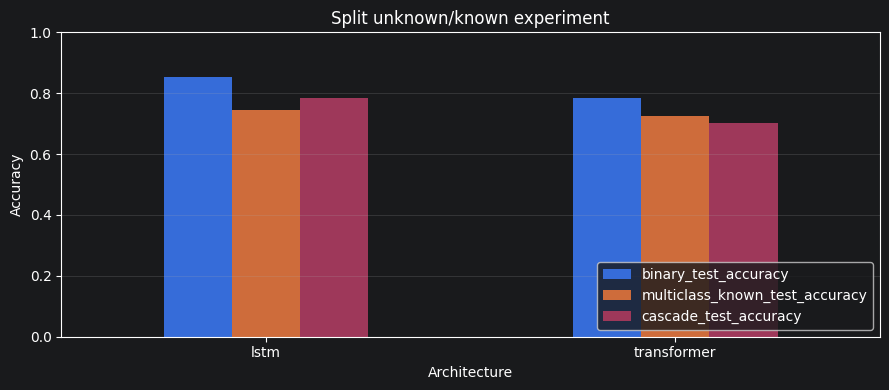

In [19]:
plot_data = all_results.set_index("architecture")[[
    "binary_test_accuracy",
    "multiclass_known_test_accuracy",
    "cascade_test_accuracy",
]]

axis = plot_data.plot(kind="bar", figsize=(9, 4), ylim=(0, 1), rot=0)
axis.set_title("Split unknown/known experiment")
axis.set_xlabel("Architecture")
axis.set_ylabel("Accuracy")
axis.grid(axis="y", alpha=0.25)
axis.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Macierze pomyłek

Po uruchomieniu eksperymentu poniższa komórka wyświetla zapisane macierze pomyłek kaskady dla obu architektur.

In [20]:
for architecture in ARCHITECTURES:
    matrix_path = (
        Path(OUTPUT_DIR)
        / f"04_split_unknown_known_{architecture}"
        / f"{architecture}_cascade"
        / "metrics"
        / "cascade_confusion_matrix.csv"
    )
    if matrix_path.exists():
        print(architecture)
        display(pd.read_csv(matrix_path, index_col=0))

lstm


,yes,no,up,down,left,right,on,off,stop,go,unknown
yes,12,0,0,0,1,0,0,0,0,0,3
no,1,12,0,1,1,0,0,0,0,1,0
up,0,1,12,0,0,0,1,2,0,0,1
down,0,1,0,6,0,0,0,0,0,2,7
left,2,0,0,0,10,1,0,0,1,1,2
right,0,0,0,0,1,10,0,0,0,0,5
on,0,0,0,0,0,1,8,0,0,0,6
off,0,0,1,0,0,0,0,14,0,0,1
stop,0,1,1,0,0,0,0,0,8,0,5
go,0,2,0,3,0,2,0,0,0,7,2


transformer


,yes,no,up,down,left,right,on,off,stop,go,unknown
yes,10,0,0,0,0,0,0,0,0,0,6
no,0,8,0,3,0,0,0,0,0,5,0
up,0,0,13,0,1,0,1,0,0,0,2
down,0,4,0,8,0,0,0,0,1,2,1
left,1,0,2,1,7,2,0,0,0,0,4
right,0,0,0,0,0,10,0,1,0,0,5
on,0,2,0,0,0,0,4,0,0,1,8
off,0,0,1,0,0,0,0,12,0,1,2
stop,0,0,0,1,0,0,0,0,13,0,1
go,0,2,1,1,0,0,0,0,0,6,6


## Krótka interpretacja do raportu

Po wykonaniu treningu porównaj `cascade_test_accuracy` z baseline z poprzednich notebooków. Jeśli wynik nie poprawia się istotnie, raportowana obserwacja jest taka, że samo rozdzielenie problemu na bramkę `unknown`/`known` i osobny klasyfikator 10 komend nie wystarcza do poprawy accuracy. Szczególnie warto odnotować, czy wariant Transformer kończy trening wcześnie przez early stopping, bo wtedy wynik może być ograniczony przez hiperparametry, a nie samą ideę kaskady.